[[6. 1.]
 [1. 4.]]
[-162.   84.]
[  0.         -31.82608696  28.95652174   0.        ]


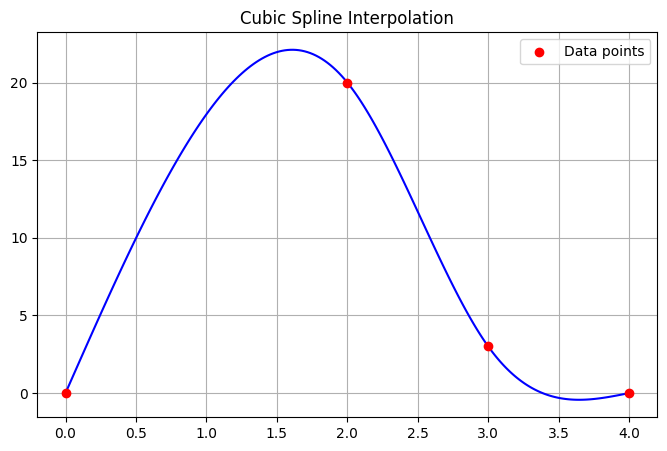

In [4]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([0,2,3,4],dtype = float)
y = np.array([0,20,3,0],dtype = float)

n = len(x)
h = np.diff(x)
m = n-2
a = np.zeros((m,m))
for i in range(m):
  a[i][i] = 2*(h[i] + h[i+1])
  if i < m-1 :
    a[i][i+1] = h[i+1]
  if i>0:
    a[i][i-1] = h[i]
print(a)

b = np.zeros(m)
for i in range(m):
  b[i] = 6*((y[i+2] - y[i+1])/h[i+1] - (y[i+1] - y[i])/h[i])
print(b)

M_interior = np.linalg.solve(a,b)
M = np.concatenate((np.array([0]), M_interior, np.array([0])))
print (M)

# Plot the original points
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='red', zorder=5, label='Data points')

# For each interval, evaluate the spline piece
for i in range(n - 1):
    # Dense x values just for this interval
    x_plot = np.linspace(x[i], x[i+1],100)

    # The spline formula we derived
    a = (x[i+1] - x_plot)
    b_term = (x_plot - x[i])

    S = (M[i] * a**3 / (6*h[i])) + \
        (M[i+1] * b_term**3 / (6*h[i])) + \
        (y[i]/h[i] - M[i]*h[i]/6) * a + \
        (y[i+1]/h[i] - M[i+1]*h[i]/6) * b_term

    ax.plot(x_plot, S, 'b-')

ax.set_title('Cubic Spline Interpolation')
ax.legend()
ax.grid(True)
plt.show()